
In this notebook, You will do amazon review classification with BERT.[Download data from [this](https://www.kaggle.com/snap/amazon-fine-food-reviews/data) link]
<pre> 
It contains 5 parts as below.  Detailed instrctions are given in the each cell. please read every comment we have written. 
    1. Preprocessing 
    2. Creating a BERT model from the Tensorflow HUB.
    3. Tokenization
    4. getting the pretrained embedding Vector for a given review from the BERT.
    5. Using the embedding data apply NN and classify the reviews.
    6. Creating a Data pipeline for BERT Model. 

<font size=5>instructions:</font>

    1. Don't change any Grader Functions. Don't manipulate any Grader functions. 
    If you manipulate any, it will be considered as plagiarised. 
    
    2. Please read the instructions on the code cells and markdown cells. We will explain what to write. 
    
    3. please return outputs in the same format what we asked. Eg. Don't return List if we are asking for a numpy array.
    
    4. Please read the external links that we are given so that you will learn the concept behind the code that you are writing.
    
    5. We are giving instructions at each section if necessary, please follow them. 

<font size=5>Every Grader function has to return True. </font>
</pre>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
#all imports
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from tensorflow.keras.models import Model

In [ ]:
tf.test.gpu_device_name()

''

<font size=4>Grader function 1 </font>

In [ ]:
def grader_tf_version():
    assert((tf.__version__)>'2')
    return True
grader_tf_version()

True

<pre><font size=6>Part-1: Preprocessing</font></pre>

In [ ]:
#Read the dataset - Amazon fine food reviews
#reviews = pd.read_csv(r"D:\ML\Internal DL\NLP\amazon-fine-food-reviews\Reviews.csv")
reviews = pd.read_csv("Reviews.csv")
#check the info of the dataset
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568438 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
# reviews.dropna(inplace=True)

In [ ]:
#get only 2 columns - Text, Score
#drop the NAN values
reviews_two_col = reviews[['Text','Score']]


In [ ]:
import pandas as pd
print(pd.__version__)

1.1.5


In [ ]:
reviews_two_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Text    568454 non-null  object
 1   Score   568454 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 8.7+ MB


In [ ]:
#if score> 3, set score = 1
#if score<=2, set score = 0
#if score == 3, remove the rows.

def getting_score(score_val):
    #print(score_val)
    if score_val > 3:
        return 1
    if score_val <= 2:
        return 0
    if score_val == 3:
        return 2
reviews_two_col['Score'] =reviews_two_col['Score'].map(getting_score)
print(reviews_two_col.Score.value_counts())
# reviews = 
# print()    

1    443777
0     82037
2     42640
Name: Score, dtype: int64


C:\Users\utsav\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]


In [ ]:
new_reviews = reviews_two_col[reviews_two_col.Score != 2]

In [ ]:
new_reviews.Score.value_counts()

1    443777
0     82037
Name: Score, dtype: int64

In [ ]:
reviews=new_reviews

In [ ]:
reviews_two_col.shape

(568454, 2)

<font size=4>Grader function 2 </font>

In [ ]:
def grader_reviews():
    temp_shape = (reviews.shape == (525814, 2)) and (reviews.Score.value_counts()[1]==443777)
    assert(temp_shape == True)
    return True
grader_reviews()

True

In [ ]:
def get_wordlen(x):
    return len(x.split())
reviews['len'] = reviews.Text.apply(get_wordlen)
reviews = reviews[reviews.len<50]
reviews = reviews.sample(n=100000, random_state=30)

C:\Users\utsav\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [ ]:
reviews.shape

(100000, 3)

In [ ]:
reviews.columns

Index(['Text', 'Score', 'len'], dtype='object')

In [ ]:
from tqdm import tqdm

In [ ]:
#remove HTML from the Text column and save in the Text column only

import re
clean_review = []
for index,value in enumerate(reviews["Text"]):
    value =  re.sub('<[^>]*>', '', value)
    clean_review.append(value) 

In [ ]:
len(clean_review)

100000

In [ ]:
reviews.drop(columns=['Text'])

,Score,len
64117,1,30
418112,1,31
357829,1,41
175872,1,27
178716,1,22
...,...,...
336657,1,39
498034,1,28
357766,1,21
326811,1,23


In [ ]:
reviews["Text"] = clean_review

In [ ]:
#print head 5
reviews.head(5)

,Text,Score,len
64117,The tea was of great quality and it tasted lik...,1,30
418112,My cat loves this. The pellets are nice and s...,1,31
357829,Great product. Does not completely get rid of ...,1,41
175872,This gum is my favorite! I would advise every...,1,27
178716,I also found out about this product because of...,1,22


In [ ]:
reviews = pd.read_csv("/content/gdrive/My Drive/preprocessed.csv")

In [ ]:
#split the data into train and test data(20%) with Stratify sampling, random state 33, 
X_train, X_test, Y_train, Y_test = train_test_split(
      reviews["Text"],reviews["Score"], test_size=0.20, stratify=reviews["Score"],random_state=33)

<AxesSubplot:>

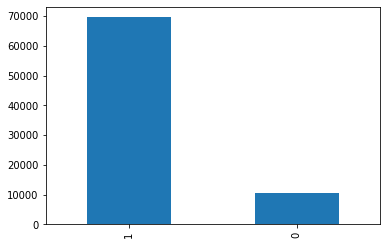

In [ ]:
Y_train.value_counts().plot(kind='bar')

<AxesSubplot:>

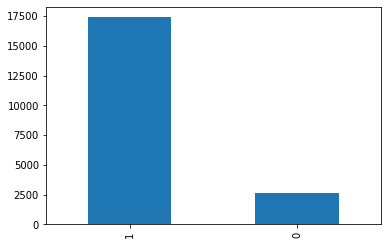

In [ ]:
Y_test.value_counts().plot(kind='bar')

In [ ]:
#plot bar graphs of y_train and y_test

In [ ]:
#saving to disk. if we need, we can load preprocessed data directly. 
reviews.to_csv('preprocessed.csv', index=False)

<pre><font size=6>Part-2: Creating BERT Model</font> 

If you want to know more about BERT, You can watch live sessions on Transformers and BERt. 
we will strongly recommend you to read <a href="https://jalammar.github.io/illustrated-transformer/">Transformers</a>, <a href="https://arxiv.org/abs/1810.04805">BERT Paper</a> and, <a href="https://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/">This blog</a>.


For this assignment, we are using <a href="https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/1">BERT uncased Base model</a>. 
It uses L=12 hidden layers (i.e., Transformer blocks), a hidden size of H=768, and A=12 attention heads. </pre>

In [4]:
## Loading the Pretrained Model from tensorflow HUB
tf.keras.backend.clear_session()

# maximum length of a seq in the data we have, for now i am making it as 55. You can change this
max_seq_length = 49

#BERT takes 3 inputs

#this is input words. Sequence of words represented as integers
input_word_ids = tf.keras.layers.Input(shape=(max_seq_length,), dtype=tf.int32, name="input_word_ids")

#mask vector if you are padding anything
input_mask = tf.keras.layers.Input(shape=(max_seq_length,), dtype=tf.int32, name="input_mask")

#segment vectors. If you are giving only one sentence for the classification, total seg vector is 0. 
#If you are giving two sentenced with [sep] token separated, first seq segment vectors are zeros and 
#second seq segment vector are 1's
segment_ids = tf.keras.layers.Input(shape=(max_seq_length,), dtype=tf.int32, name="segment_ids")

#bert layer 
bert_layer = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/1", trainable=False)
pooled_output, sequence_output = bert_layer([input_word_ids, input_mask, segment_ids])

#Bert model
#We are using only pooled output not sequence out. 
#If you want to know about those, please read https://www.kaggle.com/questions-and-answers/86510
bert_model = Model(inputs=[input_word_ids, input_mask, segment_ids], outputs=pooled_output)


In [5]:
bert_model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_word_ids (InputLayer)     [(None, 49)]         0                                            
__________________________________________________________________________________________________
input_mask (InputLayer)         [(None, 49)]         0                                            
__________________________________________________________________________________________________
segment_ids (InputLayer)        [(None, 49)]         0                                            
__________________________________________________________________________________________________
keras_layer (KerasLayer)        [(None, 768), (None, 109482241   input_word_ids[0][0]             
                                                                 input_mask[0][0]             

In [6]:
bert_model.output

<KerasTensor: shape=(None, 768) dtype=float32 (created by layer 'keras_layer')>

<pre><font size=6>Part-3: Tokenization</font></pre>

In [7]:
#getting Vocab file
vocab_file = bert_layer.resolved_object.vocab_file.asset_path.numpy()
do_lower_case = bert_layer.resolved_object.do_lower_case.numpy()

In [ ]:
import os
print(os.getcwd())

/content


In [3]:
!pip install sentencepiece

     |████████████████████████████████| 1.2MB 11.7MB/s 


In [8]:
from gdrive.MyDrive import tokenization

In [9]:
#import tokenization - We have given tokenization.py file

In [10]:
# Create tokenizer " Instantiate FullTokenizer" 
# name must be "tokenizer"
# the FullTokenizer takes two parameters 1. vocab_file and 2. do_lower_case 
# we have created these in the above cell ex: FullTokenizer(vocab_file, do_lower_case )
# please check the "tokenization.py" file the complete implementation

In [11]:
tokenizer = tokenization.FullTokenizer(vocab_file,do_lower_case)

<font size=4>Grader function 3 </font>

In [ ]:
#it has to give no error 
def grader_tokenize(tokenizer):
    out = False
    try:
        out=('[CLS]' in tokenizer.vocab) and ('[SEP]' in tokenizer.vocab)
    except:
        out = False
    assert(out==True)
    return out
grader_tokenize(tokenizer)

True

In [ ]:
# Create train and test tokens (X_train_tokens, X_test_tokens) from (X_train, X_test) using Tokenizer and 

# add '[CLS]' at start of the Tokens and '[SEP]' at the end of the tokens. 

# maximum number of tokens is 55(We already given this to BERT layer above) so shape is (None, 55)

# if it is less than 55, add '[PAD]' token else truncate the tokens length.(similar to padding)

# Based on padding, create the mask for Train and Test ( 1 for real token, 0 for '[PAD]'), 
# it will also same shape as input tokens (None, 55) save those in X_train_mask, X_test_mask

# Create a segment input for train and test. We are using only one sentence so all zeros. This shape will also (None, 55)

# type of all the above arrays should be numpy arrays

# after execution of this cell, you have to get 
# X_train_tokens, X_train_mask, X_train_segment
# X_test_tokens, X_test_mask, X_test_segment
def tokenization_masking(text_data,max_length):
    tokens = tokenizer.tokenize(text_data)
    #print(len(tokens))
    token_length = len(tokens)
    if len(tokens) < (max_length -2):
        #print("if")
        #tokens = tokens[0:max_length-2]
        tokens = ['[CLS]',*tokens,'[SEP]']
        padding_seq = ['[PAD]']*((max_length-2)- token_length)
        tokens.extend(padding_seq)
        tokenize_id = np.array(tokenizer.convert_tokens_to_ids(tokens))
        mask_array =  np.array([1]*(token_length+2)+[0]*(max_length-2-token_length))
        segmented_array = np.array([0]*(max_length))
    else: 
        #print("else")
        tokens = tokens[0:max_length-2]
        tokens = ['[CLS]',*tokens,'[SEP]']
        tokenize_id = np.array(tokenizer.convert_tokens_to_ids(tokens))
        mask_array =  np.array([1]*max_length)
        segmented_array = np.array([0]*(max_length))
    return tokenize_id, mask_array , segmented_array
#a,b,c = tokenization_masking(X_train[0],55)       

In [ ]:
X_train_tokens= np.zeros((len(X_train), 49))
X_train_mask= np.zeros((len(X_train), 49))
X_train_segment= np.zeros((len(X_train), 49))
for index,value in tqdm(enumerate(X_train)):
    tok,mask,seg = tokenization_masking(value,49)
    X_train_tokens[index] = tok
    X_train_mask[index] = mask
    X_train_segment[index]= seg

80000it [00:37, 2128.89it/s]


In [ ]:
X_test_tokens= np.zeros((len(X_test), 49))
X_test_mask= np.zeros((len(X_test), 49))
X_test_segment= np.zeros((len(X_test), 49))
for index,value in tqdm(enumerate(X_test)):
    tok,mask,seg = tokenization_masking(value,49)
    X_test_tokens[index] = tok
    X_test_mask[index] = mask
    X_test_segment[index]= seg

20000it [00:09, 2139.64it/s]


#### Example
<img src='https://i.imgur.com/5AhhmgU.png'>

In [13]:
import pickle

In [ ]:
##save all your results to disk so that, no need to run all again. 
pickle.dump((X_train, X_train_tokens, X_train_mask, X_train_segment, Y_train),open('/content/gdrive/My Drive/train_data_new.pkl','wb'))
pickle.dump((X_test, X_test_tokens, X_test_mask, X_test_segment, Y_test),open('/content/gdrive/My Drive/test_data_new.pkl','wb'))

In [14]:
#you can load from disk
X_train, X_train_tokens, X_train_mask, X_train_segment, Y_train = pickle.load(open("/content/gdrive/My Drive/train_data_new.pkl", 'rb')) 
X_test, X_test_tokens, X_test_mask, X_test_segment, Y_test = pickle.load(open("/content/gdrive/My Drive/test_data_new.pkl", 'rb')) 

In [ ]:
X_train_mask.shape

(80000, 49)

<font size=4>Grader function 4 </font>

In [ ]:
def grader_alltokens_train():
    out = False
    
    if type(X_train_tokens) == np.ndarray:
        
        temp_shapes = (X_train_tokens.shape[1]==max_seq_length) and (X_train_mask.shape[1]==max_seq_length) and \
        (X_train_segment.shape[1]==max_seq_length)
        
        segment_temp = not np.any(X_train_segment)
        
        mask_temp = np.sum(X_train_mask==0) == np.sum(X_train_tokens==0)
        
        no_cls = np.sum(X_train_tokens==tokenizer.vocab['[CLS]'])==X_train_tokens.shape[0]
        
        no_sep = np.sum(X_train_tokens==tokenizer.vocab['[SEP]'])==X_train_tokens.shape[0]
        print(temp_shapes,segment_temp,mask_temp,no_cls , no_sep)
        out = temp_shapes and segment_temp and mask_temp and no_cls and no_sep
      
    else:
        print('Type of all above token arrays should be numpy array not list')
        out = False
    assert(out==True)
    return out

grader_alltokens_train()

True True True True True


True

<font size=4>Grader function 5 </font>

In [ ]:
def grader_alltokens_test():
    out = False
    if type(X_test_tokens) == np.ndarray:
        
        temp_shapes = (X_test_tokens.shape[1]==max_seq_length) and (X_test_mask.shape[1]==max_seq_length) and \
        (X_test_segment.shape[1]==max_seq_length)
        
        segment_temp = not np.any(X_test_segment)
        
        mask_temp = np.sum(X_test_mask==0) == np.sum(X_test_tokens==0)
        
        no_cls = np.sum(X_test_tokens==tokenizer.vocab['[CLS]'])==X_test_tokens.shape[0]
        
        no_sep = np.sum(X_test_tokens==tokenizer.vocab['[SEP]'])==X_test_tokens.shape[0]
        
        out = temp_shapes and segment_temp and mask_temp and no_cls and no_sep
        print(temp_shapes,segment_temp,mask_temp,no_cls , no_sep)
      
    else:
        print('Type of all above token arrays should be numpy array not list')
        out = False
    assert(out==True)
    return out
grader_alltokens_test()

True True True True True


True

<pre><font size=6>Part-4: Getting Embeddings from BERT Model</font>
We already created the BERT model in the part-2 and input data in the part-3. 
We will utlize those two and will get the embeddings for each sentence in the 
Train and test data.</pre>

In [15]:
bert_model.input

[<KerasTensor: shape=(None, 49) dtype=int32 (created by layer 'input_word_ids')>,
 <KerasTensor: shape=(None, 49) dtype=int32 (created by layer 'input_mask')>,
 <KerasTensor: shape=(None, 49) dtype=int32 (created by layer 'segment_ids')>]

In [16]:
bert_model.output

<KerasTensor: shape=(None, 768) dtype=float32 (created by layer 'keras_layer')>

In [18]:
# # get the train output, BERT model will give one output so save in
# # X_train_pooled_output
X_train_pooled_output=bert_model.predict([X_train_tokens,X_train_mask,X_train_segment])

In [ ]:
# get the test output, BERT model will give one output so save in
# X_test_pooled_output
X_test_pooled_output=bert_model.predict([X_test_tokens,X_test_mask,X_test_segment])

In [1]:
pickle.dump((X_train_pooled_output, Y_train),open('/content/gdrive/My Drive/pool_train_data_new.pkl','wb'))
pickle.dump((X_test_pooled_output, Y_test),open('/content/gdrive/My Drive/pool_test_data_new.pkl','wb'))

In [ ]:
##save all your results to disk so that, no need to run all again. 
pickle.dump((X_train_pooled_output, X_test_pooled_output),open('/content/gdrive/My Drive/final_output_new.pkl','wb'))

In [19]:
import pickle
X_train_pooled_output, X_test_pooled_output= pickle.load(open('/content/gdrive/My Drive/final_output_new.pkl', 'rb'))


<font size=4>Grader function 6 </font>

In [20]:
#now we have X_train_pooled_output, y_train
#X_test_pooled_ouput, y_test

#please use this grader to evaluate
def greader_output():
    assert(X_train_pooled_output.shape[1]==768)
    assert(len(Y_train)==len(X_train_pooled_output))
    assert(X_test_pooled_output.shape[1]==768)
    assert(len(Y_test)==len(X_test_pooled_output))
    assert(len(Y_train.shape)==1)
    assert(len(X_train_pooled_output.shape)==2)
    assert(len(Y_test.shape)==1)
    assert(len(X_test_pooled_output.shape)==2)
    return True
greader_output()

True

<pre><font size=6>Part-5: Training a NN with 768 features</font>

Create a NN and train the NN. 
1.<b> You have to use AUC as metric.</b> 
2. You can use any architecture you want. 
3. You have to use tensorboard to log all your metrics and Losses. You have to send those logs. 
4. Print the loss and metric at every epoch. 
5. You have to submit without overfitting and underfitting. 
</pre>

In [21]:
##imports
from tensorflow.keras.layers import Input, Dense, Activation, Dropout,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
Y_train = tf.keras.utils.to_categorical(Y_train, 2)  
Y_test = tf.keras.utils.to_categorical(Y_test, 2)

In [23]:
from sklearn.metrics import roc_auc_score
def auroc(y_true,y_pred):
  return tf.py_function(roc_auc_score,(y_true,y_pred),tf.double)

In [ ]:
X_train_pooled_output.shape

(80000, 768)

In [ ]:

#print(X_tr_shape)

In [24]:
X_train_pooled_output= X_train_pooled_output.reshape(X_train_pooled_output.shape[0],1,X_train_pooled_output.shape[1])
X_test_pooled_output= X_test_pooled_output.reshape(X_test_pooled_output.shape[0],1,X_test_pooled_output.shape[1])

In [ ]:
Y_test.shape

(20000, 2)

In [37]:
L=1 
filepath="best_model_{L}.h5".format(L=L)
checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_acc',  verbose=1, save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_acc', min_delta=0, patience=2, verbose=1)
log_dir= "logs_l"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)
callback_list = [checkpoint,earlystop,tensorboard_callback]

In [38]:
##create an NN and 
input_layer_1 = Input(shape=(1,768,))
#Dense hidden layer
lstm_1a  = layers.LSTM(128,return_sequences=True)(input_layer_1)
flat1a   = Flatten()(lstm_1a)
layer1 = Dense(1024,kernel_initializer=tf.keras.initializers.glorot_normal(seed=60))(flat1a)
l1 = tf.keras.layers.LeakyReLU(alpha=0.1)(layer1)
layer2 = Dense(512,kernel_initializer=tf.keras.initializers.glorot_normal(seed=30))(l1)
l2 = tf.keras.layers.LeakyReLU(alpha=0.1)(layer2)
layer3 = Dense(256,kernel_initializer=tf.keras.initializers.glorot_normal(seed=20))(l2)
l3 = tf.keras.layers.LeakyReLU(alpha=0.1)(layer3)
#output layer
output_1 = Dense(2,activation='softmax')(l3)
#Creating a model

model = Model(inputs=input_layer_1,outputs=output_1)

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer="adam", loss='binary_crossentropy',metrics=[auroc])

model.fit(X_train_pooled_output,Y_train,epochs=20, validation_data=(X_test_pooled_output,Y_test), batch_size=100,callbacks = callback_list)


Epoch 1/20
800/800 [==============================] - 10s 11ms/step - loss: 0.3048 - auroc: 0.8336 - val_loss: 0.2145 - val_auroc: 0.9342


Epoch 2/20
800/800 [==============================] - 8s 10ms/step - loss: 0.2159 - auroc: 0.9382 - val_loss: 0.1985 - val_auroc: 0.9401


Epoch 3/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1996 - auroc: 0.9459 - val_loss: 0.2139 - val_auroc: 0.9426


Epoch 4/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1964 - auroc: 0.9477 - val_loss: 0.2119 - val_auroc: 0.9442


Epoch 5/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1889 - auroc: 0.9505 - val_loss: 0.2073 - val_auroc: 0.9457


...

Epoch 16/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1794 - auroc: 0.9571 - val_loss: 0.1765 - val_auroc: 0.9518


Epoch 17/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1775 - auroc: 0.9571 - val_loss: 0.1867 - val_auroc: 0.9524


Epoch 18/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1740 - auroc: 0.9579 - val_loss: 0.1821 - val_auroc: 0.9518


Epoch 19/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1721 - auroc: 0.9569 - val_loss: 0.1729 - val_auroc: 0.9529


Epoch 20/20
800/800 [==============================] - 8s 10ms/step - loss: 0.1756 - auroc: 0.9582 - val_loss: 0.1733 - val_auroc: 0.9536


In [41]:
# %load_ext tensorboard
# %tensorboard --logdir $log_dir

In [2]:
# import shutil
# shutil.move("logs_latest","/content/gdrive/My Drive")

<Pre><font size=6>Part-6: Creating a Data pipeline for BERT Model</font> 

1. Download data from <a href="https://drive.google.com/file/d/1QwjqTsqTX2vdy7fTmeXjxP3dq8IAVLpo/view?usp=sharing">here</a>
2. Read the csv file
3. Remove all the html tags
4. Now do tokenization [Part 3 as mentioned above]
    * Create tokens,mask array and segment array
5. Get Embeddings from BERT Model [Part 4 as mentioned above] , let it be X_test
   * Print the shape of output(X_test.shape).You should get (352,768)
6. Predit the output of X_test with the Neural network model which we trained earlier.
7. Print the occurences of class labels in the predicted output

</pre>

In [26]:
X_test_check = pd.read_csv(r"/content/gdrive/My Drive/test.csv")

In [27]:
X_test_check.shape

(352, 1)

In [28]:
# from tensorflow import keras
# MODEL = model.load_weights("/content/gdrive/My Drive/model_1.h5")

In [31]:
import re
def tokenization_masking(X,max_size):
  X_token= np.zeros((len(X), max_size))
  X_mask= np.zeros((len(X), max_size))
  X_segment= np.zeros((len(X), max_size))
  for ind, text in enumerate(tqdm(X)):
    mask= []
    segment = []
    token = tokenizer.tokenize(text)
    token_len = len(token)
    if token_len < max_size-2:
      padding_size = max_size-2 - token_len
      token = ['[CLS]']+ token + ['[SEP]'] + ['[PAD]'] *padding_size
      mask = [1]* (token_len+2) + [0] *padding_size
    else:
      token = token[:(max_size-2)]
      token = ['[CLS]'] + token + ['[SEP]']
      mask =  [1] *max_size
    segment = [0] * max_size

    X_token[ind] =tokenizer.convert_tokens_to_ids(token)
    X_mask[ind] = np.array(mask)
    X_segment[ind] = np.array(segment)
  return X_token,X_mask,X_segment

def html_clean(text_data): 
  for ind,text in enumerate(tqdm(text_data)):
    text = re.sub('<.*?>', '', text)
    text_data[ind] = text
  return text_data

In [32]:
X_final_check = pd.read_csv(r"/content/gdrive/My Drive/test.csv")
X_final_check = html_clean(X_final_check['Text'].values)


100%|██████████| 352/352 [00:00<00:00, 191020.18it/s]


In [33]:
X_final_check_tok,X_final_check_mask, X_final_check_segment= tokenization_masking(X_final_check,max_seq_length)
X_final_pooled_output=bert_model.predict([X_final_check_tok,X_final_check_mask, X_final_check_segment])
print( X_final_pooled_output.shape)
X_final_pooled_output= X_final_pooled_output.reshape(X_final_pooled_output.shape[0],1,X_final_pooled_output.shape[1])
print(X_final_pooled_output.shape)
X_predict_ouput= model.predict(X_final_pooled_output)

100%|██████████| 352/352 [00:00<00:00, 1568.98it/s]


(352, 768)
(352, 1, 768)


In [34]:
X_pred_single_label= np.argmax(X_predict_ouput, axis=1)
print('positive label:',np.sum(X_pred_single_label==1))
print('positive label:',np.sum(X_pred_single_label==0))

positive label: 311
positive label: 41


Observation

1)  Remove the score 3 and only use the score which are grethar  than 3 and less than 2

2) Remove html tags

3) Use pretrained model of BERT which receive input as word index .BERT model provide word embeddings size of 768 for the input sentence

4) Provide Embedding input to our Neural network and train the model which provide a accuracy of 95 percent